🚀 Using device: cuda
✅ Loaded 1990 test samples.
✅ BiLSTM model loaded.


  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:00<00:00, 286.18it/s]


📊 Test Metrics:
MAE: 63.6844, MAPE: 60.61%, R2: 0.1283, Directional Accuracy: 64.25%


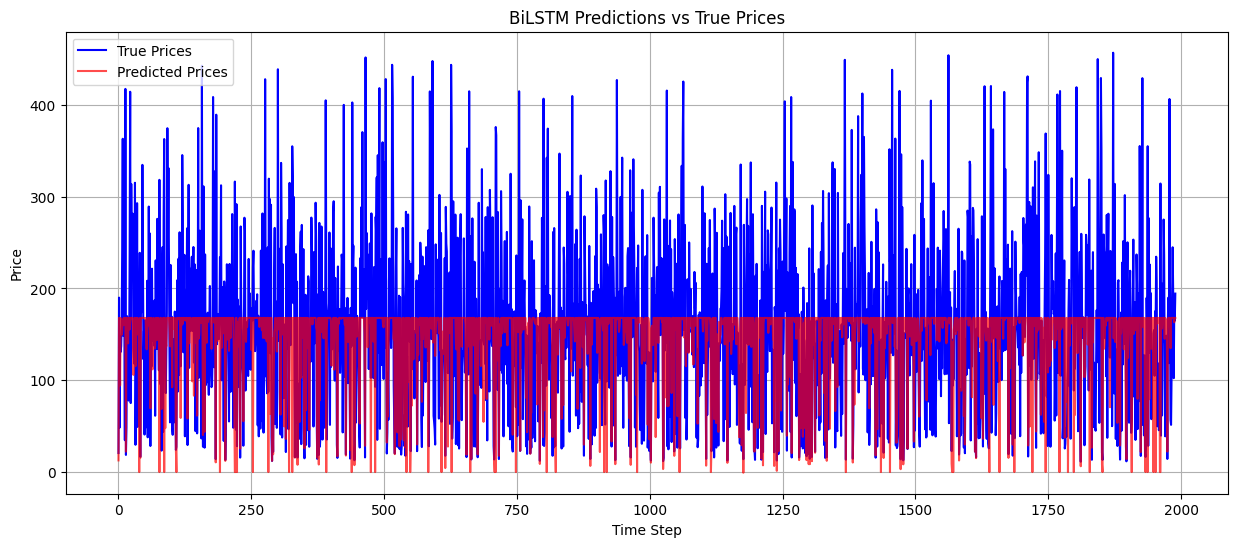

✅ Predictions saved to bilstm_predictions.csv


In [7]:
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# =====================================================
# CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_PKL = "/home/sunkari/Stock_price_predictor/Transformer/windows_b/test_windows.pkl"
MODEL_PATH = "bilstm_model.pt"
SCALER_DIR = "/home/sunkari/Stock_price_predictor/Transformer/scaler_b"
BATCH_SIZE = 64

# =====================================================
# 1️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_PKL, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 2️⃣ CREATE DATASET & DATALOADER
# =====================================================
class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx][:2]
        company = self.data[idx][2] if len(self.data[idx]) == 3 else "unknown"
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            company
        )

test_loader = DataLoader(WindowDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

# =====================================================
# 3️⃣ LOAD MODEL
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
input_size = checkpoint["input_size"]
hidden_size = checkpoint["hidden_size"]
num_layers = checkpoint["num_layers"]

class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)

model = BiLSTMRegressor(input_size, hidden_size, num_layers).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ BiLSTM model loaded.")

# =====================================================
# 4️⃣ LOAD SCALERS
# =====================================================
scalers = {}
for scaler_file in os.listdir(SCALER_DIR):
    if scaler_file.endswith("_y_scaler.pkl"):
        company_name = scaler_file.replace("_y_scaler.pkl", "")
        with open(os.path.join(SCALER_DIR, scaler_file), "rb") as f:
            scalers[company_name] = pickle.load(f)

# =====================================================
# 5️⃣ PREDICTION LOOP
# =====================================================
all_targets, all_preds, all_companies = [], [], []

with torch.no_grad():
    for X_batch, y_batch, company_batch in tqdm(test_loader):
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch).cpu().numpy()
        y_batch = y_batch.numpy()

        for i in range(len(preds)):
            y_val = 0.0 if not np.isfinite(y_batch[i]) else y_batch[i]
            pred_val = 0.0 if not np.isfinite(preds[i]) else preds[i]

            company_name = company_batch[i] if company_batch[i] in scalers else None
            scaler = scalers.get(company_name, None)

            if scaler:
                # Safe inverse_transform
                y_true_denorm = scaler.inverse_transform(np.array([[y_val]]))[0][0]
                y_pred_denorm = scaler.inverse_transform(np.array([[pred_val]]))[0][0]
            else:
                y_true_denorm = y_val
                y_pred_denorm = pred_val

            all_targets.append(y_true_denorm)
            all_preds.append(y_pred_denorm)
            all_companies.append(company_name)

# =====================================================
# 6️⃣ EVALUATION METRICS
# =====================================================
all_targets_np = np.array(all_targets)
all_preds_np = np.array(all_preds)

mae = mean_absolute_error(all_targets_np, all_preds_np)
mask = all_targets_np != 0
mape = np.mean(np.abs((all_targets_np[mask] - all_preds_np[mask]) / all_targets_np[mask])) * 100
r2 = r2_score(all_targets_np, all_preds_np)

# Directional Accuracy
direction_correct = np.sum(np.diff(all_targets_np) * np.diff(all_preds_np) > 0)
directional_accuracy = direction_correct / (len(all_targets_np) - 1) * 100

print("\n📊 Test Metrics:")
print(f"MAE: {mae:.4f}, MAPE: {mape:.2f}%, R2: {r2:.4f}, Directional Accuracy: {directional_accuracy:.2f}%")

# =====================================================
# 7️⃣ PLOT TRUE VS PREDICTED
# =====================================================
plt.figure(figsize=(15,6))
plt.plot(all_targets_np, label="True Prices", color="blue")
plt.plot(all_preds_np, label="Predicted Prices", color="red", alpha=0.7)
plt.title("BiLSTM Predictions vs True Prices")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()
# =====================================================
# 8️⃣ SAVE RESULTS TO CSV
# =====================================================
results_df = pd.DataFrame({
    "Company": all_companies,
    "True_Price": all_targets_np,
    "Predicted_Price": all_preds_np
})

csv_path = "bilstm_predictions.csv"
results_df.to_csv(csv_path, index=False)
print(f"✅ Predictions saved to {csv_path}")

🚀 Using device: cuda
✅ Loaded 1990 test samples.
✅ BiLSTM model loaded.


100%|██████████| 32/32 [00:00<00:00, 276.80it/s]


📊 Test Metrics:
MAE: 33.6572, MAPE: 28.91%, R2: 0.5389, Directional Accuracy: 83.81%


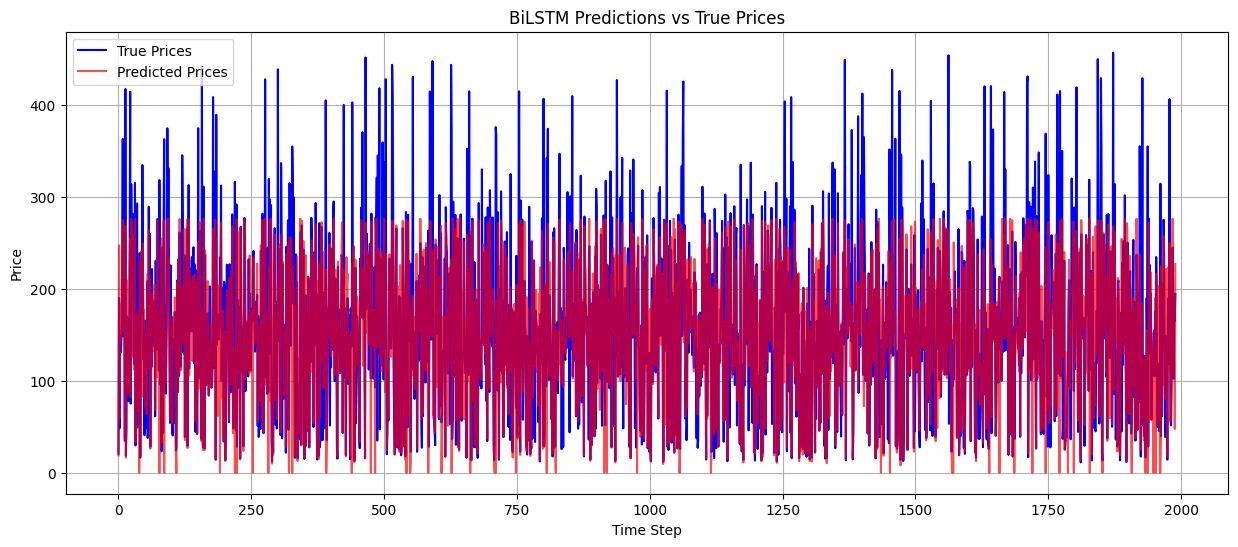

✅ Predictions saved to bilstm_predictions.csv


In [8]:
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# =====================================================
# CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_PKL = "/home/sunkari/Stock_price_predictor/Transformer/windows_b/test_windows.pkl"
MODEL_PATH = "bilstm_model.pt"
SCALER_DIR = "/home/sunkari/Stock_price_predictor/Transformer/scaler_b"
BATCH_SIZE = 64

# =====================================================
# 1️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_PKL, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 2️⃣ CREATE DATASET & DATALOADER
# =====================================================
class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx][:2]
        company = self.data[idx][2] if len(self.data[idx]) == 3 else "unknown"
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            company
        )

test_loader = DataLoader(WindowDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

# =====================================================
# 3️⃣ LOAD MODEL
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
input_size = checkpoint["input_size"]
hidden_size = checkpoint["hidden_size"]
num_layers = checkpoint["num_layers"]

class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)

model = BiLSTMRegressor(input_size, hidden_size, num_layers).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ BiLSTM model loaded.")

# =====================================================
# 4️⃣ LOAD SCALERS
# =====================================================
scalers = {}
for scaler_file in os.listdir(SCALER_DIR):
    if scaler_file.endswith("_y_scaler.pkl"):
        company_name = scaler_file.replace("_y_scaler.pkl", "")
        with open(os.path.join(SCALER_DIR, scaler_file), "rb") as f:
            scalers[company_name] = pickle.load(f)

# =====================================================
# 5️⃣ PREDICTION LOOP
# =====================================================
all_targets, all_preds, all_companies = [], [], []

with torch.no_grad():
    for X_batch, y_batch, company_batch in tqdm(test_loader):
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch).cpu().numpy()
        y_batch = y_batch.numpy()

        for i in range(len(preds)):
            y_val = 0.0 if not np.isfinite(y_batch[i]) else y_batch[i]
            pred_val = 0.0 if not np.isfinite(preds[i]) else preds[i]

            company_name = company_batch[i] if company_batch[i] in scalers else None
            scaler = scalers.get(company_name, None)

            if scaler:
                # Safe inverse_transform
                y_true_denorm = scaler.inverse_transform(np.array([[y_val]]))[0][0]
                y_pred_denorm = scaler.inverse_transform(np.array([[pred_val]]))[0][0]
            else:
                y_true_denorm = y_val
                y_pred_denorm = pred_val

            all_targets.append(y_true_denorm)
            all_preds.append(y_pred_denorm)
            all_companies.append(company_name)

# =====================================================
# 6️⃣ EVALUATION METRICS
# =====================================================
all_targets_np = np.array(all_targets)
all_preds_np = np.array(all_preds)

mae = mean_absolute_error(all_targets_np, all_preds_np)
mask = all_targets_np != 0
mape = np.mean(np.abs((all_targets_np[mask] - all_preds_np[mask]) / all_targets_np[mask])) * 100
r2 = r2_score(all_targets_np, all_preds_np)

# Directional Accuracy
direction_correct = np.sum(np.diff(all_targets_np) * np.diff(all_preds_np) > 0)
directional_accuracy = direction_correct / (len(all_targets_np) - 1) * 100

print("\n📊 Test Metrics:")
print(f"MAE: {mae:.4f}, MAPE: {mape:.2f}%, R2: {r2:.4f}, Directional Accuracy: {directional_accuracy:.2f}%")

# =====================================================
# 7️⃣ PLOT TRUE VS PREDICTED
# =====================================================
plt.figure(figsize=(15,6))
plt.plot(all_targets_np, label="True Prices", color="blue")
plt.plot(all_preds_np, label="Predicted Prices", color="red", alpha=0.7)
plt.title("BiLSTM Predictions vs True Prices")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()
# =====================================================
# 8️⃣ SAVE RESULTS TO CSV
# =====================================================
results_df = pd.DataFrame({
    "Company": all_companies,
    "True_Price": all_targets_np,
    "Predicted_Price": all_preds_np
})

csv_path = "bilstm_predictions.csv"
results_df.to_csv(csv_path, index=False)
print(f"✅ Predictions saved to {csv_path}")

🚀 Using device: cuda
✅ Loaded 1990 test samples.
✅ BiLSTM model loaded.


100%|██████████| 32/32 [00:00<00:00, 244.56it/s]


📊 Test Metrics:
MAE: 28.5992, MAPE: 23.67%, R2: 0.6030, Directional Accuracy: 86.12%


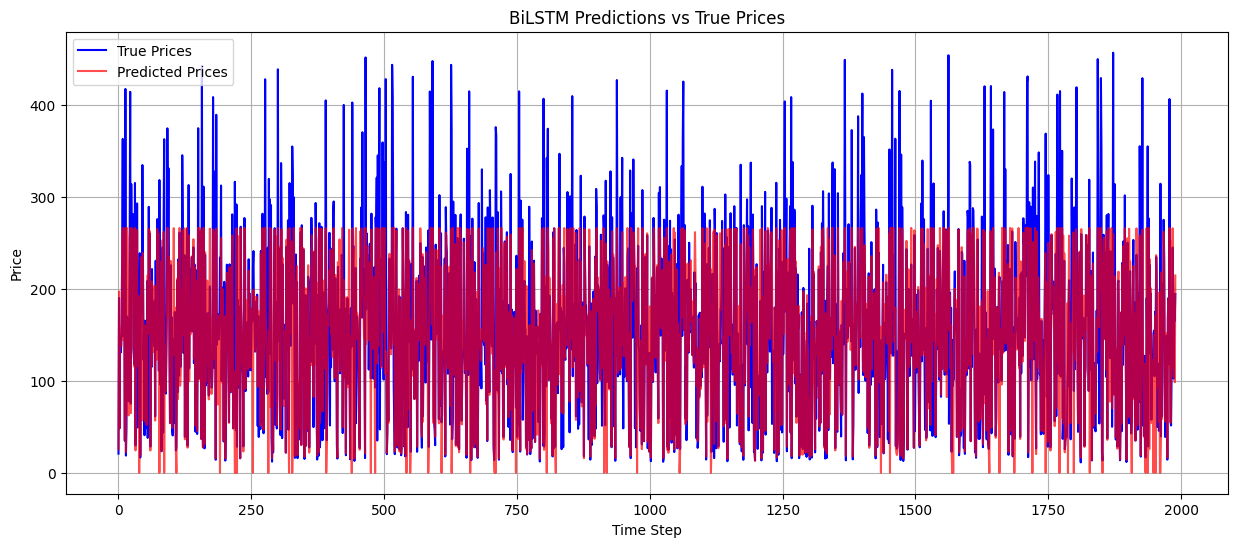

✅ Predictions saved to bilstm_predictions.csv


In [ ]:
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# =====================================================
# CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_PKL = "/home/sunkari/Stock_price_predictor/Transformer/windows_b/test_windows.pkl"
MODEL_PATH = "bilstm_model.pt"
SCALER_DIR = "/home/sunkari/Stock_price_predictor/Transformer/scaler_b"
BATCH_SIZE = 64

# =====================================================
# 1️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_PKL, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 2️⃣ CREATE DATASET & DATALOADER
# =====================================================
class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx][:2]
        company = self.data[idx][2] if len(self.data[idx]) == 3 else "unknown"
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            company
        )

test_loader = DataLoader(WindowDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

# =====================================================
# 3️⃣ LOAD MODEL
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
input_size = checkpoint["input_size"]
hidden_size = checkpoint["hidden_size"]
num_layers = checkpoint["num_layers"]

class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)

model = BiLSTMRegressor(input_size, hidden_size, num_layers).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ BiLSTM model loaded.")

# =====================================================
# 4️⃣ LOAD SCALERS
# =====================================================
scalers = {}
for scaler_file in os.listdir(SCALER_DIR):
    if scaler_file.endswith("_y_scaler.pkl"):
        company_name = scaler_file.replace("_y_scaler.pkl", "")
        with open(os.path.join(SCALER_DIR, scaler_file), "rb") as f:
            scalers[company_name] = pickle.load(f)

# =====================================================
# 5️⃣ PREDICTION LOOP
# =====================================================
all_targets, all_preds, all_companies = [], [], []

with torch.no_grad():
    for X_batch, y_batch, company_batch in tqdm(test_loader):
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch).cpu().numpy()
        y_batch = y_batch.numpy()

        for i in range(len(preds)):
            y_val = 0.0 if not np.isfinite(y_batch[i]) else y_batch[i]
            pred_val = 0.0 if not np.isfinite(preds[i]) else preds[i]

            company_name = company_batch[i] if company_batch[i] in scalers else None
            scaler = scalers.get(company_name, None)

            if scaler:
                # Safe inverse_transform
                y_true_denorm = scaler.inverse_transform(np.array([[y_val]]))[0][0]
                y_pred_denorm = scaler.inverse_transform(np.array([[pred_val]]))[0][0]
            else:
                y_true_denorm = y_val
                y_pred_denorm = pred_val

            all_targets.append(y_true_denorm)
            all_preds.append(y_pred_denorm)
            all_companies.append(company_name)

# =====================================================
# 6️⃣ EVALUATION METRICS
# =====================================================
all_targets_np = np.array(all_targets)
all_preds_np = np.array(all_preds)

mae = mean_absolute_error(all_targets_np, all_preds_np)
mask = all_targets_np != 0
mape = np.mean(np.abs((all_targets_np[mask] - all_preds_np[mask]) / all_targets_np[mask])) * 100
r2 = r2_score(all_targets_np, all_preds_np)

# Directional Accuracy
direction_correct = np.sum(np.diff(all_targets_np) * np.diff(all_preds_np) > 0)
directional_accuracy = direction_correct / (len(all_targets_np) - 1) * 100

print("\n📊 Test Metrics:")
print(f"MAE: {mae:.4f}, MAPE: {mape:.2f}%, R2: {r2:.4f}, Directional Accuracy: {directional_accuracy:.2f}%")

# =====================================================
# 7️⃣ PLOT TRUE VS PREDICTED
# =====================================================
plt.figure(figsize=(15,6))
plt.plot(all_targets_np, label="True Prices", color="blue")
plt.plot(all_preds_np, label="Predicted Prices", color="red", alpha=0.7)
plt.title("BiLSTM Predictions vs True Prices")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()
# =====================================================
# 8️⃣ SAVE RESULTS TO CSV
# =====================================================
results_df = pd.DataFrame({
    "Company": all_companies,
    "True_Price": all_targets_np,
    "Predicted_Price": all_preds_np
})

csv_path = "bilstm_predictions.csv"
results_df.to_csv(csv_path, index=False)
print(f"✅ Predictions saved to {csv_path}")